# Lab Report 02-2 - Running Code

This notebook contains the full runnable practical for `Lab Report 02-2` with separate Python cells and explanatory comments.

In [1]:
# Optional install command for notebook environments.
# Run this only if OpenCV is not already installed.
# !pip install opencv-python mediapipe --quiet

In [2]:
# Import required libraries.
# cv2        -> image processing and color conversions
# numpy      -> numerical calculations and array handling
# matplotlib -> image display and graph plotting
# pathlib    -> safe file path handling
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set default plot size and grayscale display style for single-channel images.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

In [3]:
# Locate Girl.jpg from likely working directories.
candidate_paths = [
    Path("Girl.jpg"),
    Path("../Girl.jpg"),
    Path(r"C:/Users/kavin/OneDrive/Documents/Projects/Digital Image Processing and Computer Vision/Girl.jpg"),
]

image_path = next((path for path in candidate_paths if path.exists()), None)

if image_path is None:
    raise FileNotFoundError(
        "Could not find 'Girl.jpg'. Keep it in the project root or current working directory."
    )

# Read the image using OpenCV.
# OpenCV loads color images in BGR format by default.
img_bgr = cv2.imread(str(image_path))

if img_bgr is None:
    raise ValueError(f"OpenCV could not read the image: {image_path}")

print(f"Loaded image from: {image_path.resolve()}")
print(f"BGR image shape: {img_bgr.shape}")

Loaded image from: C:\Users\kavin\OneDrive\Documents\Projects\Digital Image Processing and Computer Vision\Girl.jpg
BGR image shape: (512, 512, 3)


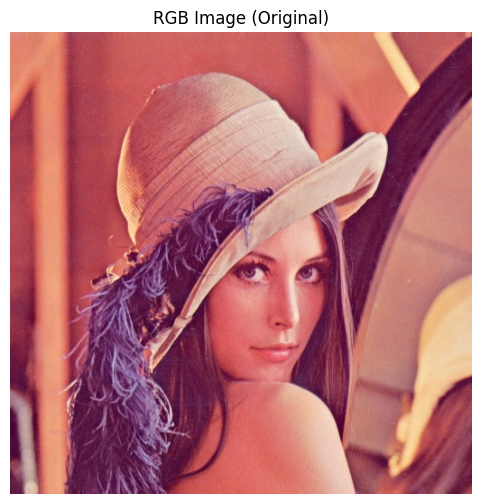

In [4]:
# Convert the image from BGR to RGB for correct display in matplotlib.
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the correctly converted RGB image.
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("RGB Image (Original)")
plt.axis("off")
plt.show()

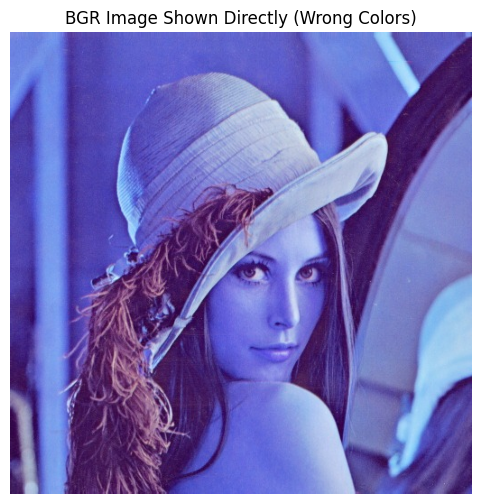

In [5]:
# Display the original BGR image directly.
# The colors appear wrong because matplotlib expects RGB order.
plt.figure(figsize=(6, 6))
plt.imshow(img_bgr)
plt.title("BGR Image Shown Directly (Wrong Colors)")
plt.axis("off")
plt.show()

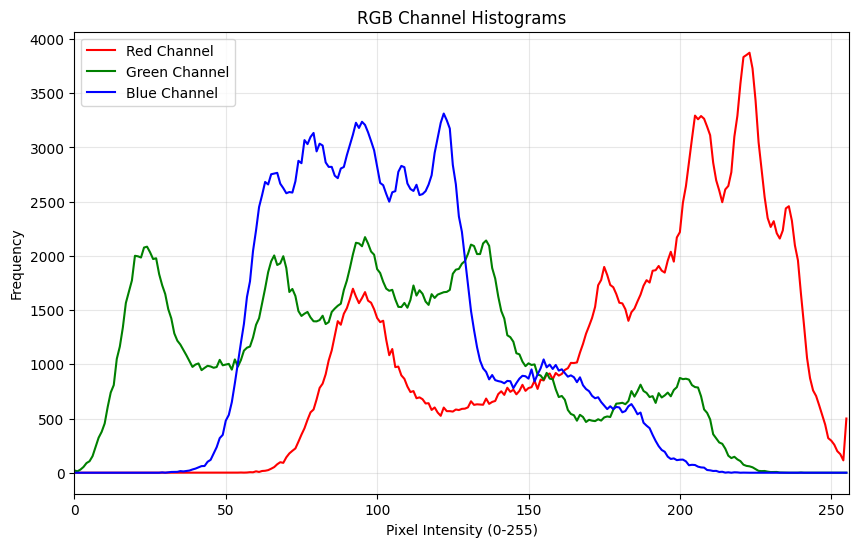

In [6]:
# Plot RGB histograms for the full color image.
colors = ("r", "g", "b")
channel_names = ["Red", "Green", "Blue"]

plt.figure(figsize=(10, 6))

for i, color in enumerate(colors):
    # 256 bins cover intensities from 0 to 255.
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, label=f"{channel_names[i]} Channel")

plt.title("RGB Channel Histograms")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
# Compute histogram-based mean and standard deviation for each RGB channel.
for i, name in enumerate(channel_names):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256]).flatten()
    intensity_values = np.arange(256)

    mean_intensity = np.average(intensity_values, weights=hist)
    std_intensity = np.sqrt(
        np.average((intensity_values - mean_intensity) ** 2, weights=hist)
    )

    print(f"{name} Channel Analysis:")
    print(f"  Mean Intensity     : {mean_intensity:.2f}")
    print(f"  Standard Deviation : {std_intensity:.2f}")
    print()

Red Channel Analysis:
  Mean Intensity     : 179.74
  Standard Deviation : 49.08

Green Channel Analysis:
  Mean Intensity     : 99.56
  Standard Deviation : 52.73

Blue Channel Analysis:
  Mean Intensity     : 105.38
  Standard Deviation : 33.89



In [8]:
# Split the RGB image into red, green, and blue channels.
r_channel, g_channel, b_channel = cv2.split(img_rgb)

print(f"Original RGB Image Shape : {img_rgb.shape}")
print(f"Red Channel Shape        : {r_channel.shape}")
print(f"Green Channel Shape      : {g_channel.shape}")
print(f"Blue Channel Shape       : {b_channel.shape}")

Original RGB Image Shape : (512, 512, 3)
Red Channel Shape        : (512, 512)
Green Channel Shape      : (512, 512)
Blue Channel Shape       : (512, 512)


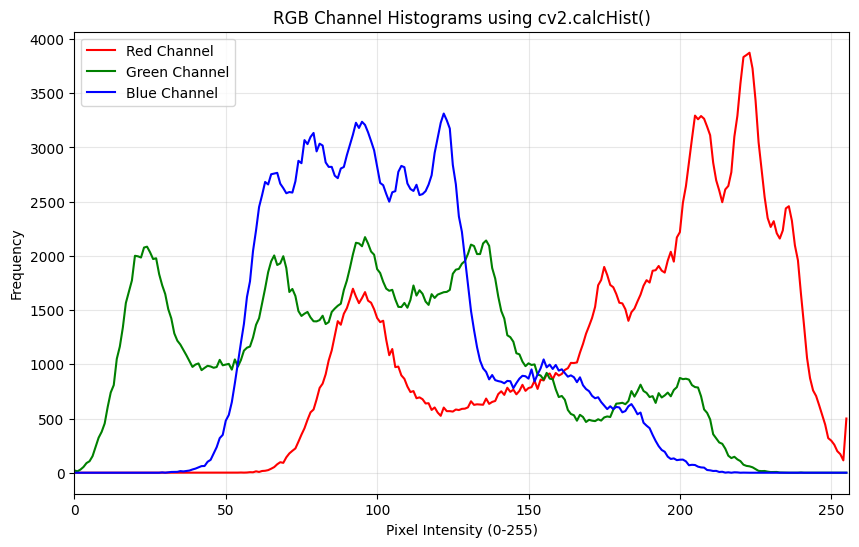

In [9]:
# Compute histograms for the separated channels.
hist_r = cv2.calcHist([r_channel], [0], None, [256], [0, 256])
hist_g = cv2.calcHist([g_channel], [0], None, [256], [0, 256])
hist_b = cv2.calcHist([b_channel], [0], None, [256], [0, 256])

plt.figure(figsize=(10, 6))
plt.plot(hist_r, color="r", label="Red Channel")
plt.plot(hist_g, color="g", label="Green Channel")
plt.plot(hist_b, color="b", label="Blue Channel")
plt.title("RGB Channel Histograms using cv2.calcHist()")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.xlim([0, 256])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

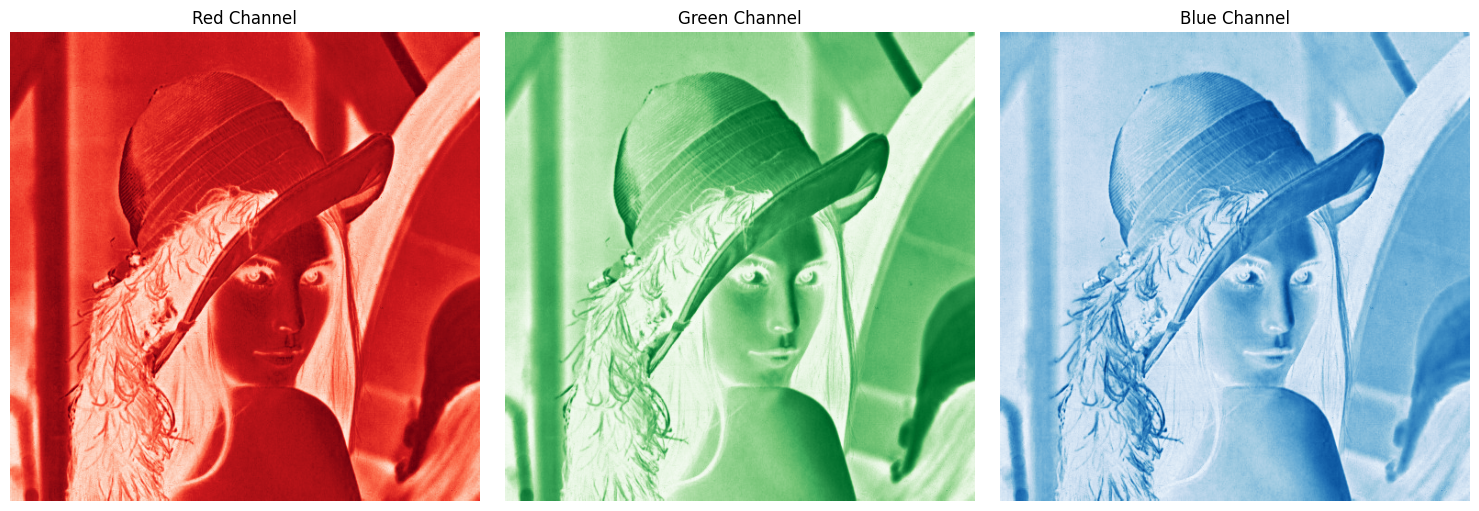

In [10]:
# Display the separated RGB channels as images.
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(r_channel, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(g_channel, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(b_channel, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# Define a reusable statistics function for a single color channel.
def channel_stats(channel, name):
    mean = np.mean(channel)
    std = np.std(channel)
    hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
    peak = int(np.argmax(hist))

    print(f"{name:5} Channel | Mean: {mean:6.2f} | Std: {std:6.2f} | Peak Intensity: {peak:3}")
    return mean, std, peak

In [12]:
# Run the channel statistics function for all RGB channels.
print("\n" + "=" * 70)
print("RGB CHANNEL STATISTICS")
print("-" * 70)

r_stats = channel_stats(r_channel, "Red")
g_stats = channel_stats(g_channel, "Green")
b_stats = channel_stats(b_channel, "Blue")

print("=" * 70)


RGB CHANNEL STATISTICS
----------------------------------------------------------------------
Red   Channel | Mean: 179.74 | Std:  49.08 | Peak Intensity: 223
Green Channel | Mean:  99.56 | Std:  52.73 | Peak Intensity:  96
Blue  Channel | Mean: 105.38 | Std:  33.89 | Peak Intensity: 122


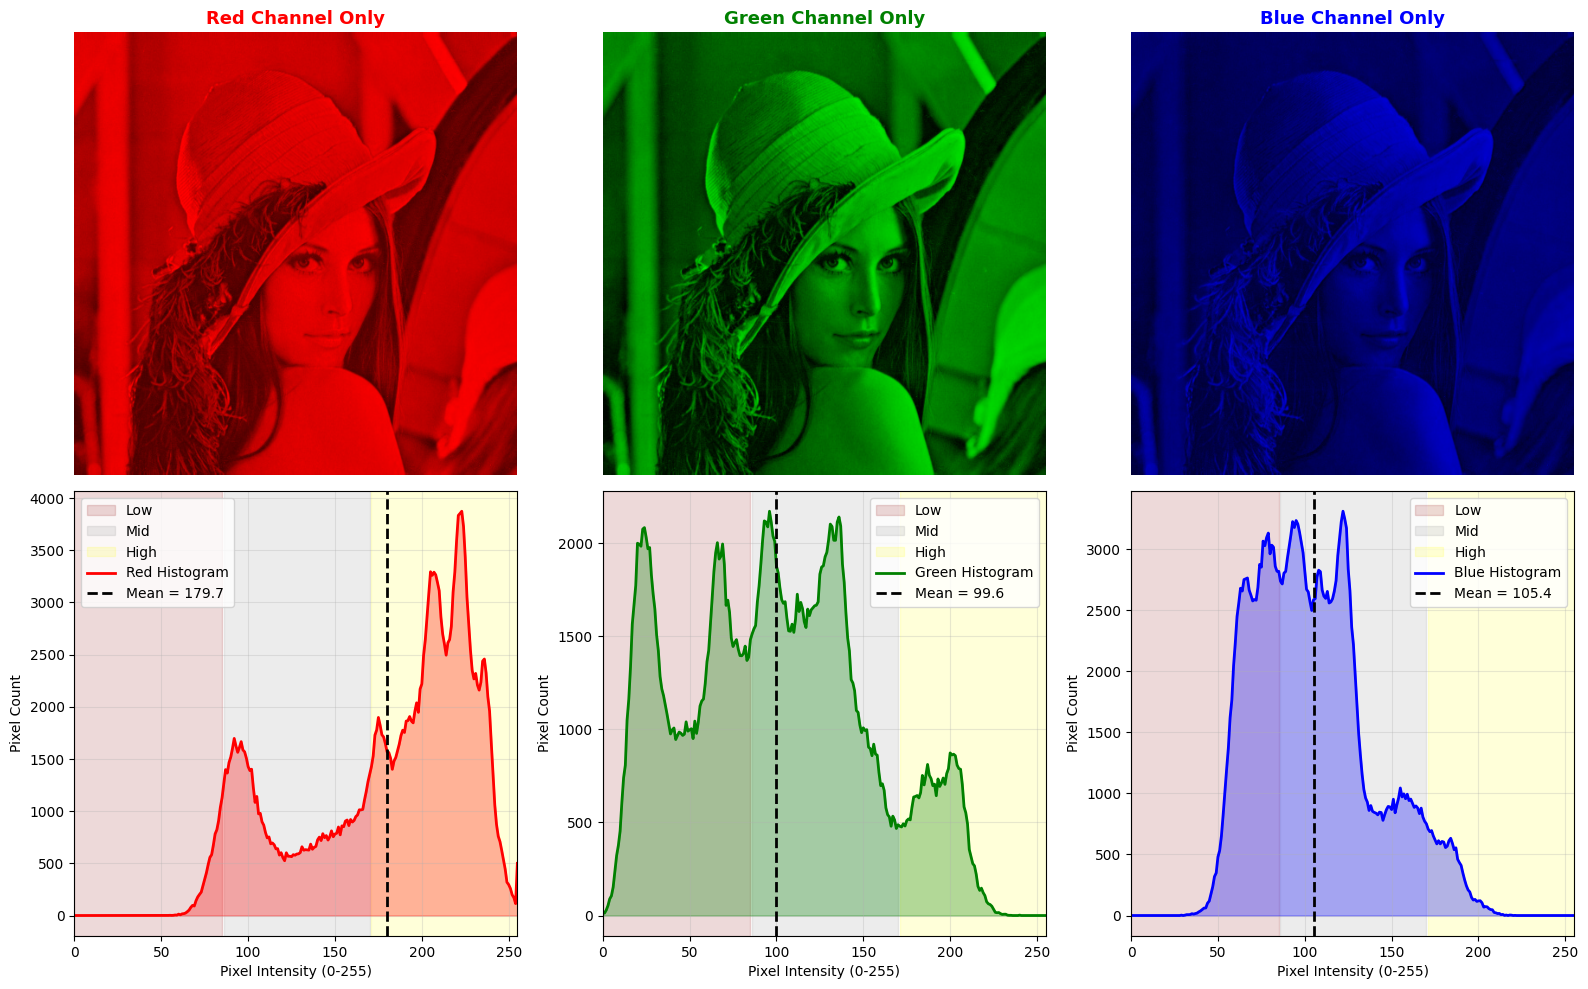

In [13]:
# Advanced visualization: channel-only images with matching histograms.
mean_r = r_stats[0]
mean_g = g_stats[0]
mean_b = b_stats[0]

plt.figure(figsize=(16, 10))

channels = [
    (r_channel, hist_r, "Red", "red", mean_r),
    (g_channel, hist_g, "Green", "green", mean_g),
    (b_channel, hist_b, "Blue", "blue", mean_b),
]

for i, (channel, hist, name, color, mean_val) in enumerate(channels):
    plt.subplot(2, 3, i + 1)
    masked = np.zeros_like(img_rgb)
    masked[:, :, i] = channel
    plt.imshow(masked)
    plt.title(f"{name} Channel Only", fontsize=13, fontweight="bold", color=color)
    plt.axis("off")

    plt.subplot(2, 3, i + 4)
    plt.axvspan(0, 85, color="darkred", alpha=0.15, label="Low")
    plt.axvspan(86, 170, color="grey", alpha=0.15, label="Mid")
    plt.axvspan(171, 255, color="yellow", alpha=0.15, label="High")
    plt.plot(hist, color=color, linewidth=2, label=f"{name} Histogram")
    plt.fill_between(range(256), hist.flatten(), color=color, alpha=0.3)
    plt.axvline(mean_val, color="black", linestyle="--", linewidth=2, label=f"Mean = {mean_val:.1f}")
    plt.xlabel("Pixel Intensity (0-255)")
    plt.ylabel("Pixel Count")
    plt.xlim([0, 255])
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

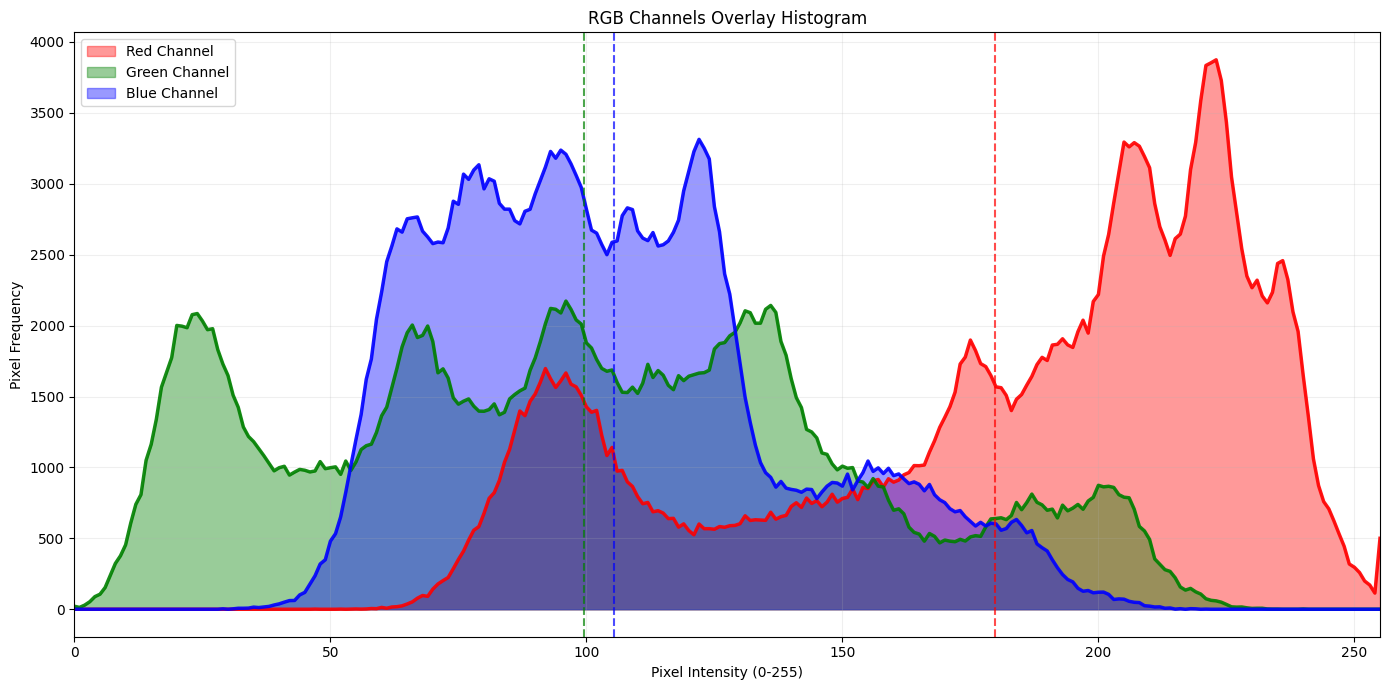

In [14]:
# Overlay all three RGB histograms in one plot for comparison.
plt.figure(figsize=(14, 7))

x = range(256)
plt.fill_between(x, hist_r.flatten(), alpha=0.4, color="red", label="Red Channel")
plt.fill_between(x, hist_g.flatten(), alpha=0.4, color="green", label="Green Channel")
plt.fill_between(x, hist_b.flatten(), alpha=0.4, color="blue", label="Blue Channel")

plt.plot(hist_r, color="red", alpha=0.9, linewidth=2.5)
plt.plot(hist_g, color="green", alpha=0.9, linewidth=2.5)
plt.plot(hist_b, color="blue", alpha=0.9, linewidth=2.5)

plt.axvline(mean_r, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
plt.axvline(mean_g, color="green", linestyle="--", alpha=0.7, linewidth=1.5)
plt.axvline(mean_b, color="blue", linestyle="--", alpha=0.7, linewidth=1.5)

plt.title("RGB Channels Overlay Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Pixel Frequency")
plt.grid(True, alpha=0.2)
plt.xlim(0, 255)
plt.legend()
plt.tight_layout()
plt.show()

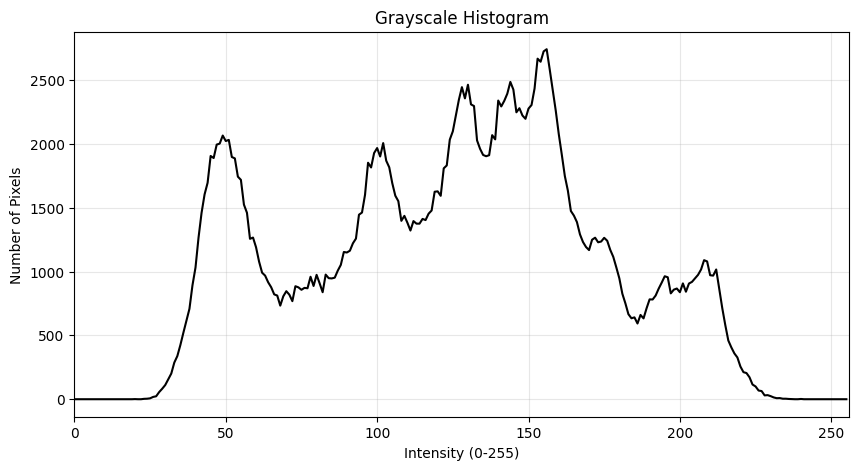

In [15]:
# Convert the RGB image to grayscale and plot its histogram.
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])

plt.figure(figsize=(10, 5))
plt.plot(hist_gray, color="black")
plt.title("Grayscale Histogram")
plt.xlabel("Intensity (0-255)")
plt.ylabel("Number of Pixels")
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)
plt.show()

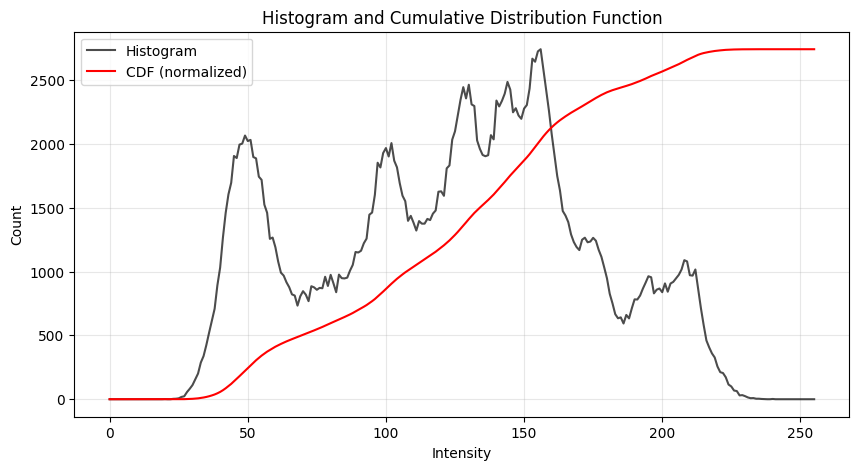

In [16]:
# Plot grayscale histogram and normalized cumulative distribution function.
cdf = hist_gray.cumsum()
cdf_normalized = cdf * hist_gray.max() / cdf.max()

plt.figure(figsize=(10, 5))
plt.plot(hist_gray, color="black", alpha=0.7, label="Histogram")
plt.plot(cdf_normalized, color="red", label="CDF (normalized)")
plt.title("Histogram and Cumulative Distribution Function")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

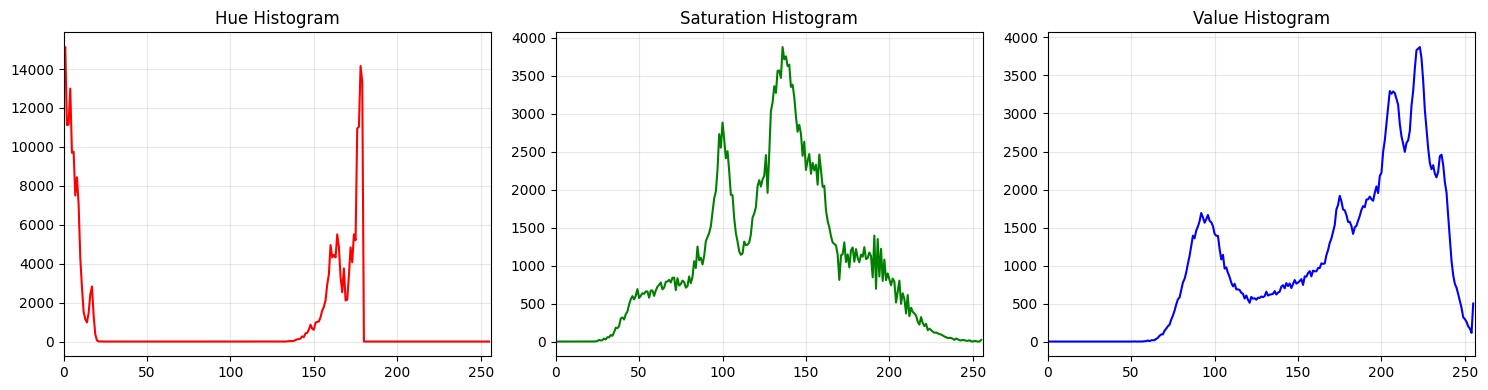

In [17]:
# Convert the original BGR image to HSV and plot Hue, Saturation, and Value histograms.
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

hsv_channels = [h, s, v]
hsv_names = ["Hue", "Saturation", "Value"]
hsv_colors = ["red", "green", "blue"]

for i in range(3):
    hist_channel = cv2.calcHist([hsv_channels[i]], [0], None, [256], [0, 256])
    ax[i].plot(hist_channel, color=hsv_colors[i])
    ax[i].set_title(f"{hsv_names[i]} Histogram")
    ax[i].set_xlim([0, 256])
    ax[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

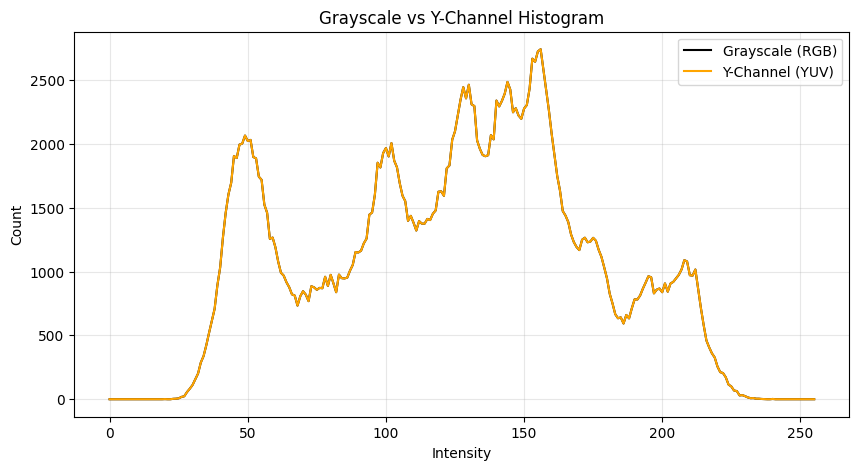

In [18]:
# Convert the original BGR image to YUV and compare the Y channel with grayscale.
yuv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)
y_channel, u_channel, v_channel = cv2.split(yuv)
hist_y = cv2.calcHist([y_channel], [0], None, [256], [0, 256])

plt.figure(figsize=(10, 5))
plt.plot(hist_gray, color="black", label="Grayscale (RGB)")
plt.plot(hist_y, color="orange", label="Y-Channel (YUV)")
plt.title("Grayscale vs Y-Channel Histogram")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# Define a helper function to simulate exposure changes by multiplication.
def adjust_exposure(image, factor):
    return np.clip(image * factor, 0, 255).astype("uint8")

# Create grayscale exposure variants.
good_exposure = gray.copy()
high_exposure = adjust_exposure(gray, 2.0)
low_exposure = adjust_exposure(gray, 0.4)

In [20]:
# Compute histograms for exposure variants.
def compute_hist(image):
    return cv2.calcHist([image], [0], None, [256], [0, 256])

hist_good_exp = compute_hist(good_exposure)
hist_high_exp = compute_hist(high_exposure)
hist_low_exp = compute_hist(low_exposure)

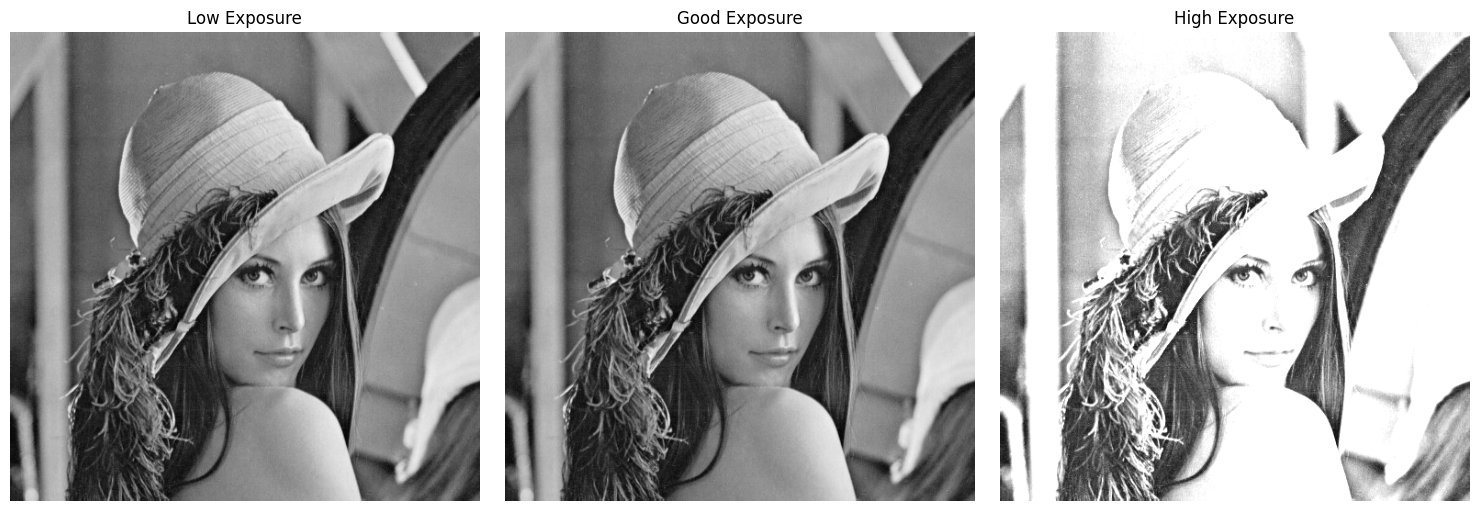

In [21]:
# Display low, normal, and high exposure grayscale images.
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(low_exposure, cmap="gray")
plt.title("Low Exposure")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(good_exposure, cmap="gray")
plt.title("Good Exposure")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(high_exposure, cmap="gray")
plt.title("High Exposure")
plt.axis("off")

plt.tight_layout()
plt.show()

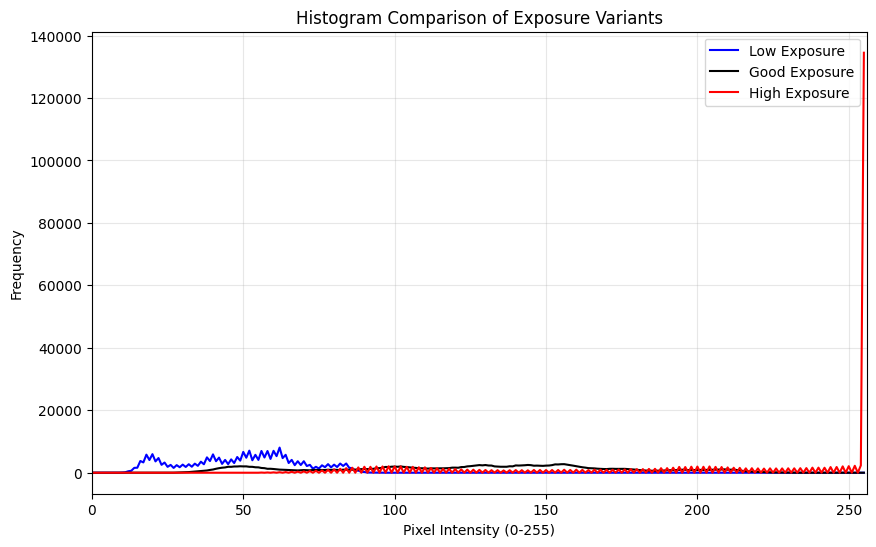

In [22]:
# Compare exposure variant histograms.
plt.figure(figsize=(10, 6))
plt.plot(hist_low_exp, color="blue", label="Low Exposure")
plt.plot(hist_good_exp, color="black", label="Good Exposure")
plt.plot(hist_high_exp, color="red", label="High Exposure")
plt.title("Histogram Comparison of Exposure Variants")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim([0, 256])
plt.show()

In [23]:
# Define a helper function to simulate brightness changes by addition or subtraction.
def adjust_brightness(image, delta):
    return np.clip(image.astype(np.int16) + delta, 0, 255).astype("uint8")

good_brightness = gray.copy()
high_brightness = adjust_brightness(gray, 100)
low_brightness = adjust_brightness(gray, -100)

In [24]:
# Compute histograms for brightness variants.
hist_good_bri = compute_hist(good_brightness)
hist_high_bri = compute_hist(high_brightness)
hist_low_bri = compute_hist(low_brightness)

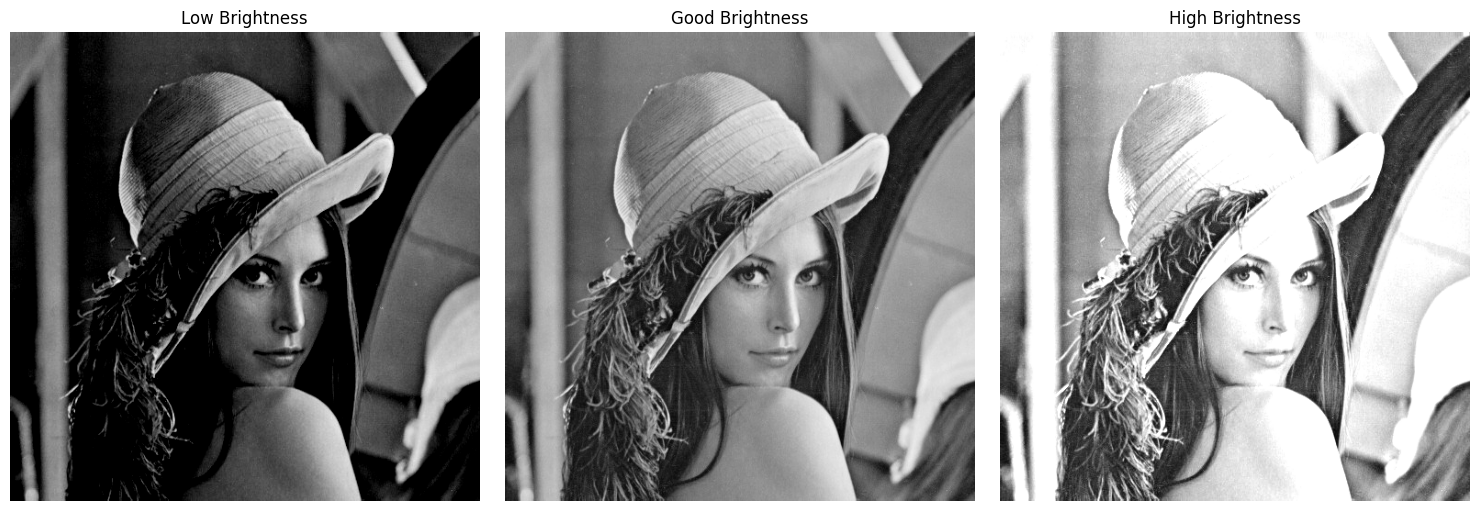

In [25]:
# Display low, normal, and high brightness grayscale images.
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(low_brightness, cmap="gray")
plt.title("Low Brightness")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(good_brightness, cmap="gray")
plt.title("Good Brightness")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(high_brightness, cmap="gray")
plt.title("High Brightness")
plt.axis("off")

plt.tight_layout()
plt.show()

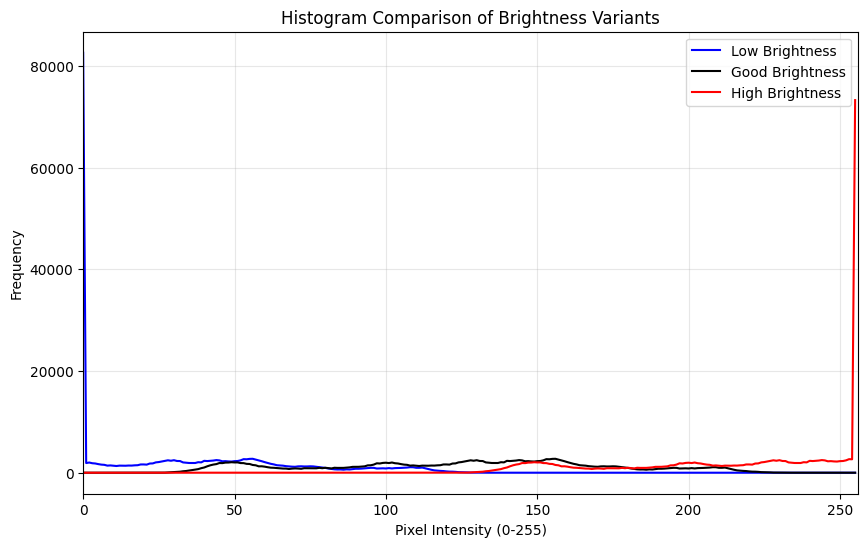

In [26]:
# Compare brightness variant histograms.
plt.figure(figsize=(10, 6))
plt.plot(hist_low_bri, color="blue", label="Low Brightness")
plt.plot(hist_good_bri, color="black", label="Good Brightness")
plt.plot(hist_high_bri, color="red", label="High Brightness")
plt.title("Histogram Comparison of Brightness Variants")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim([0, 256])
plt.show()

In [27]:
# Final summary of the completed practical.
print("\nPRACTICAL COMPLETED SUCCESSFULLY")
print("-" * 32)
print("1. Image loaded safely")
print("2. BGR converted to RGB")
print("3. RGB image displayed")
print("4. RGB histograms plotted")
print("5. Channel statistics calculated")
print("6. RGB channels split and displayed")
print("7. Grayscale histogram plotted")
print("8. CDF plotted")
print("9. HSV histograms plotted")
print("10. Y-channel compared with grayscale")
print("11. Exposure variants created and analyzed")
print("12. Brightness variants created and analyzed")


PRACTICAL COMPLETED SUCCESSFULLY
--------------------------------
1. Image loaded safely
2. BGR converted to RGB
3. RGB image displayed
4. RGB histograms plotted
5. Channel statistics calculated
6. RGB channels split and displayed
7. Grayscale histogram plotted
8. CDF plotted
9. HSV histograms plotted
10. Y-channel compared with grayscale
11. Exposure variants created and analyzed
12. Brightness variants created and analyzed
